# Titanic Survival Prediction — Supervised Machine Learning

This notebook walks through a complete supervised machine learning workflow,
from exploratory data analysis to model training and evaluation using the
Titanic dataset.


In [54]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

## 1. Data Loading

In [55]:
titanic_df = pd.read_csv(r"C:\Users\Faris\OneDrive\Desktop\Vs\Datasets\titanic\train.csv")

titanic_df.head()
                        

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Initial Data Inspection

In [56]:
titanic_df.shape

(891, 12)

In [57]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [58]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Exploratory Data Analysis (EDA)

In [ ]:
# Target Distribution

titanic_df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

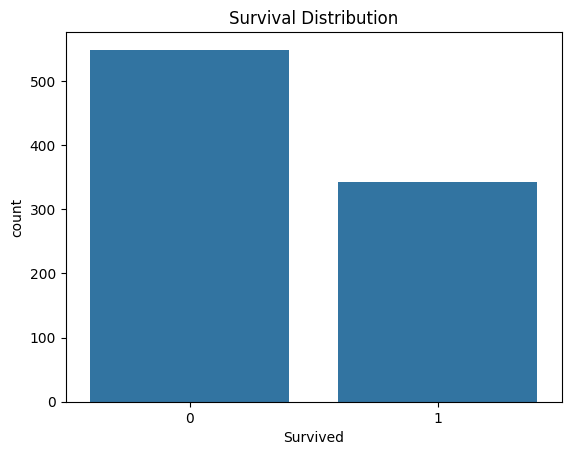

In [60]:
sns.countplot(x="Survived", data=titanic_df)
plt.title("Survival Distribution")
plt.show()

In [ ]:
# Missing Values Analysis

titanic_df.isna().sum().sort_values(ascending = False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

### Feature Relationships


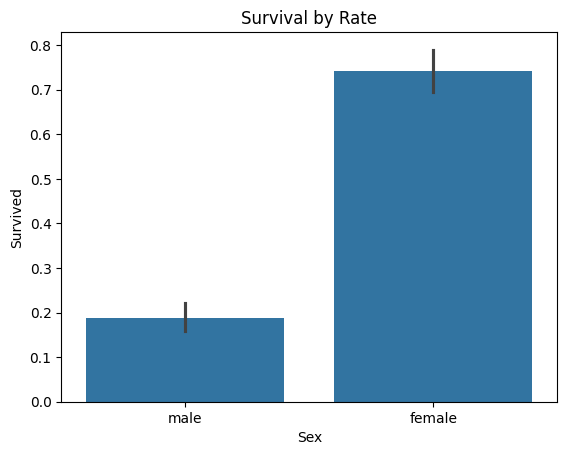

In [62]:
sns.barplot(x = "Sex", y = "Survived", data = titanic_df)

plt.title("Survival by Rate")

plt.show()

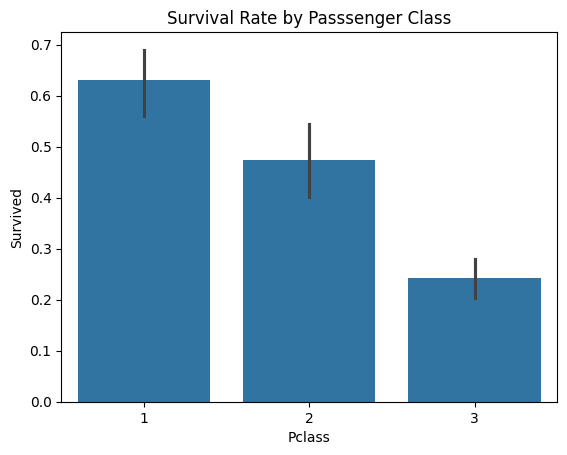

In [63]:
sns.barplot(x = "Pclass", y = "Survived", data = titanic_df)

plt.title("Survival Rate by Passsenger Class")

plt.show()

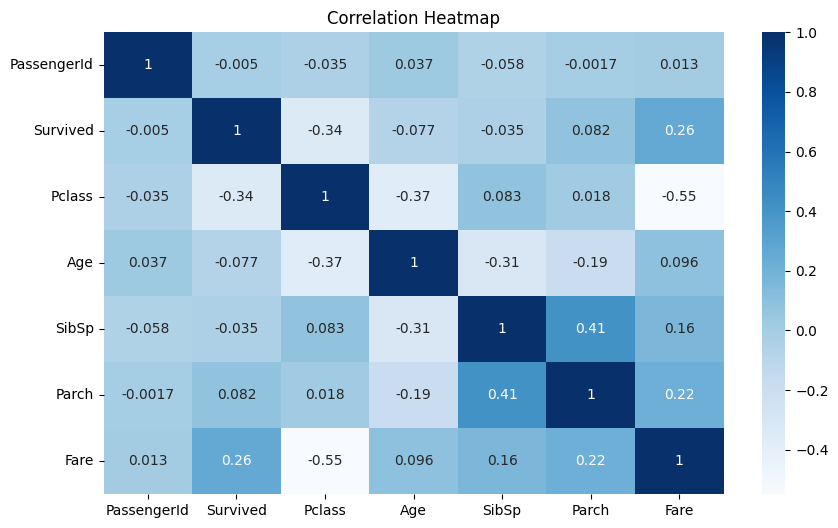

In [64]:
plt.figure(figsize=(10, 6))

sns.heatmap(titanic_df.corr(numeric_only=True), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

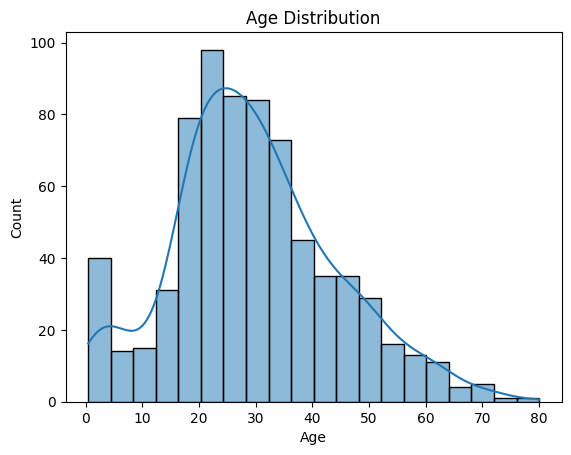

In [65]:
sns.histplot(titanic_df["Age"], kde = True)

plt.title("Age Distribution")

plt.show()

In [66]:
titanic_df["Embarked"].value_counts()


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

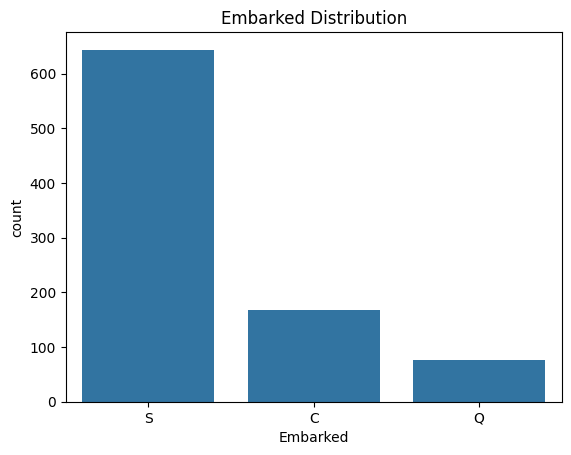

In [67]:
sns.countplot(x = "Embarked", data=titanic_df)

plt.title("Embarked Distribution")

plt.show()

## 4. Data Preparation

The following preprocessing steps were applied to prepare the data for modeling:
- Removal of non-informative features
- Handling missing values
- Encoding categorical variables


In [68]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv(r"C:\Users\Faris\OneDrive\Desktop\Vs\Datasets\titanic\train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [69]:
df.drop(columns = ["PassengerId", "Name", "Ticket", "Cabin"], inplace = True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [70]:
df["Age"].fillna(df["Age"].median(), inplace = True)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


C:\Users\Faris\AppData\Local\Temp\ipykernel_28896\1514418421.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace = True)
C:\Users\Faris\AppData\Local\Temp\ipykernel_28896\1514418421.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [71]:
df.isna().sum()


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [72]:
le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

## 5. Train–Test Split


In [73]:
X = df.drop("Survived", axis = 1)
y = df["Survived"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



## 6. Baseline Models Comparisons
Logistic Regression is used as a baseline model due to its simplicity and interpretability.
A Random Forest model is trained to capture non-linear relationships and assess feature importance.

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier



models = {"Logistic Regression": LogisticRegression(),
          "Decision Tree": DecisionTreeClassifier(),
          "Random Forest": RandomForestClassifier()}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print("{} Test Set Accuracy: {}".format(name, test_score))

Logistic Regression Test Set Accuracy: 0.8100558659217877
Decision Tree Test Set Accuracy: 0.7821229050279329
Random Forest Test Set Accuracy: 0.8156424581005587


In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


rf_model = RandomForestClassifier(n_estimators=200)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.8212290502793296
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       105
           1       0.79      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [76]:

kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf_model, X, y, cv=kf, scoring="accuracy")

print("Mean cv Accuracy: ",cv_scores.mean())


Mean cv Accuracy:  0.8159176029962547


## 9. Feature Importance


    Feature  Importance
5      Fare    0.276241
1       Sex    0.266017
2       Age    0.251524
0    Pclass    0.084744
3     SibSp    0.049699
4     Parch    0.038133
6  Embarked    0.033642


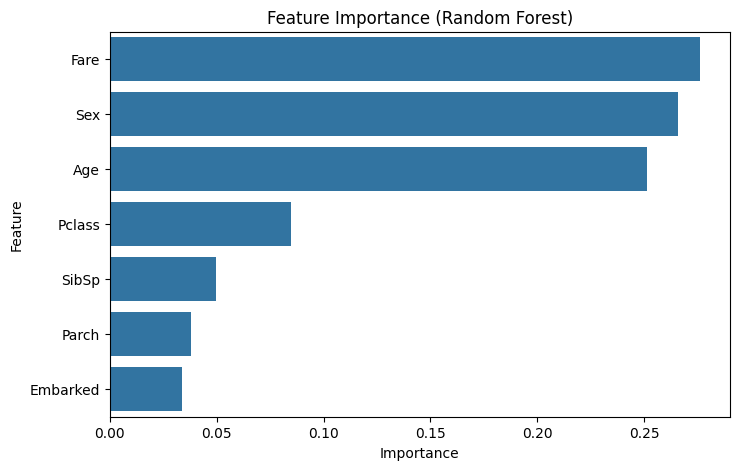

In [77]:
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)



plt.figure(figsize=(8, 5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df
)
plt.title("Feature Importance (Random Forest)")
plt.show()


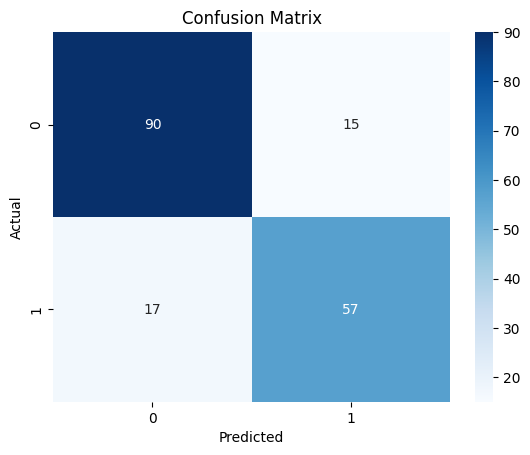

In [78]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Both Logistic Regression and Random Forest achieved similar performance.
Given the marginal difference, the simpler model remains competitive while
the Random Forest model was useful for feature importance analysis.